# Pairwise-SSP KS with within-SSP empirical null (effective-n fix)

Response to the effective-sample-size problem: the asymptotic KS p assumes iid
n=7300 daily samples, but daily tas is strongly autocorrelated and ENSO/IOD/IPO
add low-frequency variability, so n_eff << n, non-uniformly in space.

**Fix: per-pixel empirical null from within-SSP run pairs.** Two ssp370 members
differ ONLY by internal-variability draw. The distribution of the KS statistic D
across all within-ssp370 run pairs is a null for "same forcing, different
variability draw" that prices in autocorrelation and low-frequency modes
automatically, pixel by pixel. Cross-SSP D for each matched run is then ranked
against that null:

  `emp_p = (1 + #{D_null >= D_cross}) / (1 + N_null)`

Null pairs (all pairs among ssp370 runs with data at GWL2.0): CanESM5
C(15,2)=105, MPI-ESM1-2-LR C(10,2)=45, MIROC6 C(3,2)=3.
**MIROC6 caveat: N_null=3 -> min emp_p = 0.25; cannot reject at 0.05.**

Cross pairs: same matched runs as `ks_path_independence_maps.ipynb` (15/3/10 per
comparison). Aggregation across runs: Original q01 convention; plot linear 0-1
with cmap (bottom 5% purple). D machinery = `ks_fast` D (validated
exact vs scipy); the asymptotic p step is what gets replaced by the empirical
rank.

In [2]:
import os, re, itertools
import numpy as np
import xarray as xr
import arraylake, regionmask
from scipy import stats as sstats
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
from matplotlib import pyplot as plt
import matplotlib as mpl
from cartopy import crs as ccrs
import cmocean

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
from funcs_support import get_params
dir_list = get_params()

N_WORKERS = int(os.environ.get('KS_NWORKERS', '16'))

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
VAR    = 'tas'
GWL    = 2.0
ANCHOR = 'ssp370'
OTHERS = ['ssp245', 'ssp585']
PROJ   = 'ERA5'
MODELS = ['CanESM5']   # IPSL tas empty upstream
# MODELS = ['CanESM5', 'MIROC6', 'MPI-ESM1-2-LR']   # IPSL tas empty upstream

CACHE_DIR = dir_list['aux'] + 'diagnostics/ks_empirical_null/'
os.makedirs(CACHE_DIR, exist_ok=True)

In [4]:
al = arraylake.Client()
repo = al.get_repo('ClimateUncertaintyLab/bcd_me_qdm')
session = repo.readonly_session(branch='main')

In [5]:
# D-only version of ks_fast (ks_path_independence_maps.ipynb): D exact vs scipy.
# Blocked over pixels to bound memory (full 51120x14600 intermediate ~25GB).
def ks_D(a1, a2, block=2500):
    P, n1 = a1.shape; n2 = a2.shape[1]
    out = np.empty(P, dtype='f4')
    for s in range(0, P, block):
        z = np.concatenate([a1[s:s+block], a2[s:s+block]], axis=1)
        order = np.argsort(z, axis=1, kind='stable')
        zs = np.take_along_axis(z, order, axis=1)
        ind = np.where(order < n1, 1.0 / n1, -1.0 / n2)
        cd = np.cumsum(ind, axis=1)
        valid = np.ones_like(cd, dtype=bool)
        valid[:, :-1] = zs[:, 1:] != zs[:, :-1]
        out[s:s+block] = np.abs(np.where(valid, cd, 0.0)).max(axis=1)
    return out

def runs_with_data(ds, exp):
    ok = ds.has_data.values
    rs = ds.run.values[(ds.experiment.values == exp) & ok]
    return sorted(set(rs), key=lambda m: list(map(int, re.findall(r'\d+', m))))

def load_member(ds, exp, run):
    """(P, n) float32 daily values for one (experiment, run)."""
    i = np.where((ds.experiment.values == exp) & (ds.run.values == run))[0][0]
    da = ds.tas.isel(idv=i).load().transpose('lat', 'lon', 'dayofyear', 'year')
    v = da.values.astype('f4')
    return v.reshape(-1, v.shape[2] * v.shape[3]), da.lat, da.lon

In [6]:
# sanity: ks_D vs scipy on synthetic data
rng = np.random.default_rng(0)
_x1 = rng.normal(size=(3, 7300)).astype('f4')
_x2 = rng.normal(0.03, 1.0, size=(3, 7300)).astype('f4')
_D = ks_D(_x1, _x2)
for _i in range(3):
    assert np.isclose(_D[_i], sstats.kstest(_x1[_i], _x2[_i]).statistic, atol=1e-7)
print('ks_D validated vs scipy')

ks_D validated vs scipy


In [7]:
# Globals for fork-based workers: anchor members loaded once in the parent,
# children read them copy-on-write (no per-worker copies of ~1.5GB arrays).
_ANCHOR_STACK = None

def _null_pair(ij):
    i, j = ij
    return ks_D(_ANCHOR_STACK[i], _ANCHOR_STACK[j])

def compute_model(mod):
    global _ANCHOR_STACK
    ds = (xr.open_zarr(session.store, zarr_format=3, group=mod)
          .sel(gwl=GWL, variable=VAR, proj_base=PROJ)[['tas', 'experiment', 'run', 'has_data']])
    a_runs = runs_with_data(ds, ANCHOR)
    print(f'{mod}: {len(a_runs)} {ANCHOR} runs -> {len(a_runs)*(len(a_runs)-1)//2} null pairs')

    members = {}
    for r in a_runs:
        members[r], lat, lon = load_member(ds, ANCHOR, r)
    _ANCHOR_STACK = [members[r] for r in a_runs]

    pairs = list(itertools.combinations(range(len(a_runs)), 2))
    ctx = mp.get_context('fork')
    with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as ex:
        d_null = np.stack(list(ex.map(_null_pair, pairs)))          # (Npair, P)
    pair_names = [f'{a_runs[i]}|{a_runs[j]}' for i, j in pairs]

    d_cross, cross_idx = [], []
    for other in OTHERS:
        o_runs = [r for r in runs_with_data(ds, other) if r in members]
        for r in o_runs:
            vo, *_ = load_member(ds, other, r)
            d_cross.append(ks_D(members[r], vo))
            cross_idx.append((other, r))
        print(f'{mod}: {ANCHOR} vs {other} cross D done ({len(o_runs)} matched runs)')
    d_cross = np.stack(d_cross)                                     # (Ncross, P)

    _ANCHOR_STACK = None; members.clear()

    P = d_null.shape[1]
    ds_out = xr.Dataset(
        {'D_null':  (('pair', 'lat', 'lon'), d_null.reshape(-1, len(lat), len(lon))),
         'D_cross': (('cross', 'lat', 'lon'), d_cross.reshape(-1, len(lat), len(lon)))},
        coords={'lat': lat.values, 'lon': lon.values, 'pair': pair_names,
                'other': ('cross', [o for o, _ in cross_idx]),
                'run':   ('cross', [r for _, r in cross_idx])})
    ds_out.attrs['description'] = (f'KS D: within-{ANCHOR} null pairs and cross-SSP matched pairs, '
                                   f'GWL{GWL}, daily {VAR}, proj_base={PROJ}')
    return ds_out

data = {}
for mod in MODELS:
    fn = f'{CACHE_DIR}{mod}.nc'
    if os.path.exists(fn):
        data[mod] = xr.open_dataset(fn).load()
        print(f'{mod}: loaded cache ({data[mod].sizes["pair"]} null pairs, {data[mod].sizes["cross"]} cross)')
    else:
        data[mod] = compute_model(mod)
        data[mod].to_netcdf(fn)
        print(f'{mod}: saved {fn}')

CanESM5: loaded cache (105 null pairs, 30 cross)


In [8]:
# Empirical p per cross run, then authors' q01 across runs per (model, other)
emp, q01 = {}, {}
for mod, d in data.items():
    npair = d.sizes['pair']
    ge = (d.D_null >= d.D_cross).sum('pair')          # broadcast (cross,lat,lon)
    p = ((1 + ge) / (1 + npair)).rename('emp_p')
    for other in OTHERS:
        sel = p.isel(cross=(d.other == other).values).swap_dims(cross='run')
        emp[(mod, other)] = sel
        q01[(mod, other)] = sel.quantile(0.01, dim='run')

landmask_da = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(
    next(iter(data.values())).lon, next(iter(data.values())).lat)

print('EMPIRICAL-NULL results (land only):')
for (mod, other), pv in sorted(emp.items()):
    lm = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(pv.lon, pv.lat)
    land = ~np.isnan(lm.values)
    per_run = [(pv.isel(run=i).values[land] < 0.05).mean() for i in range(pv.sizes['run'])]
    ql = q01[(mod, other)].values[land]
    npair = data[mod].sizes['pair']
    print(f'  {mod:15s} vs {other} ({pv.sizes["run"]:2d} runs, {npair:3d} null pairs): '
          f'per-run mean frac emp_p<0.05 = {np.mean(per_run):.3f} | q01 median = {np.median(ql):.3f}')

EMPIRICAL-NULL results (land only):
  CanESM5         vs ssp245 (15 runs, 105 null pairs): per-run mean frac emp_p<0.05 = 0.016 | q01 median = 0.285
  CanESM5         vs ssp585 (15 runs, 105 null pairs): per-run mean frac emp_p<0.05 = 0.003 | q01 median = 0.350


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/ks_empirical_null_maps_ssp370_GWL2.png


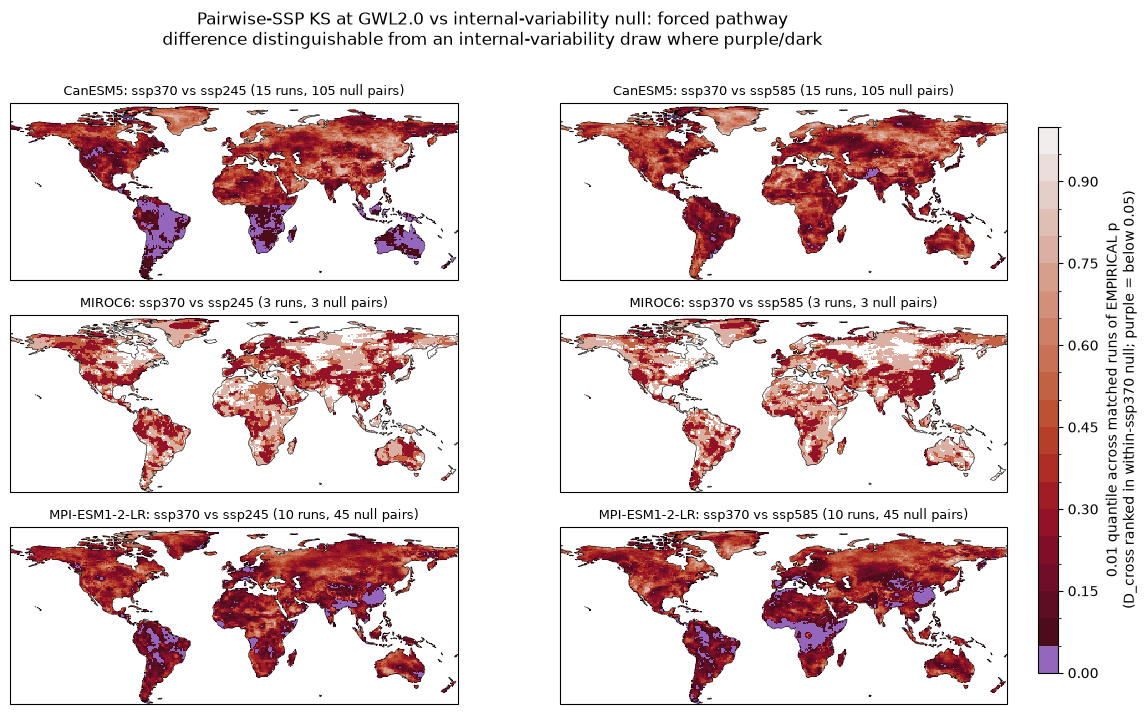

In [8]:
# authors' cmap: amp_r, bottom 5% -> tab:purple
_colors = cmocean.cm.amp_r(np.linspace(0, 1, 256))
_colors[:int(0.05 * 256), :] = mpl.colors.to_rgba('tab:purple')
cmap_mod = mpl.colors.ListedColormap(_colors)

fig, axes = plt.subplots(len(MODELS), len(OTHERS), figsize=(13, 2.6*len(MODELS)),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for r, mod in enumerate(MODELS):
    for c, other in enumerate(OTHERS):
        ax = axes[r, c]
        q = q01[(mod, other)]
        lm = regionmask.defined_regions.natural_earth_v5_0_0.land_110.mask(q.lon, q.lat)
        im = q.where(~np.isnan(lm)).plot(ax=ax, transform=ccrs.PlateCarree(),
                                          vmin=0, vmax=1, cmap=cmap_mod, levels=21,
                                          add_colorbar=False)
        n = emp[(mod, other)].sizes['run']
        ax.coastlines(linewidth=0.4)
        ax.set_title(f'{mod}: {ANCHOR} vs {other} ({n} runs, '
                     f'{data[mod].sizes["pair"]} null pairs)', fontsize=9)
        ax.set_xlabel(''); ax.set_ylabel('')
fig.subplots_adjust(right=0.9)
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cax,
             label='0.01 quantile across matched runs of EMPIRICAL p\n'
                   '(D_cross ranked in within-ssp370 null; purple = below 0.05)')
fig.suptitle(f'Pairwise-SSP KS at GWL{GWL} vs internal-variability null: forced pathway\n'
             f'difference distinguishable from an internal-variability draw where purple/dark',
             y=1.0, fontsize=12)
out_dir = dir_list['aux'] + '../figures/'
fig.savefig(out_dir + 'ks_empirical_null_maps_ssp370_GWL2.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'ks_empirical_null_maps_ssp370_GWL2.png')